In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_997.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_4384.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_3169.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_3416.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_4573.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_2416.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_980.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_419.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_3682.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_4921.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_1688.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice_2062.json
/kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels/invoice

In [2]:
!pip install -q transformers accelerate bitsandbytes
!pip install -q pillow tqdm pandas

In [3]:
import json
import re
from pathlib import Path
from PIL import Image
import torch
from tqdm import tqdm
import pandas as pd

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


In [4]:
DATASET_PATH = Path("/kaggle/input/datasets/rayenchtiba/facture-dlctricit")

IMAGES_DIR = DATASET_PATH / "images"
LABELS_DIR = DATASET_PATH / "labels"

print(f"Images path : {IMAGES_DIR}")
print(f"Labels path : {LABELS_DIR}")
print(f"Nombre d'images : {len(list(IMAGES_DIR.glob('*')))}")
print(f"Nombre de JSON  : {len(list(LABELS_DIR.glob('*')))}")

Images path : /kaggle/input/datasets/rayenchtiba/facture-dlctricit/images
Labels path : /kaggle/input/datasets/rayenchtiba/facture-dlctricit/labels
Nombre d'images : 5000
Nombre de JSON  : 5000


In [5]:
def load_dataset(max_samples=None):
    data = []
    json_files = sorted(LABELS_DIR.glob("*.json"))
    
    if max_samples:
        json_files = json_files[:max_samples]
    
    for json_path in tqdm(json_files, desc="Chargement des factures"):
        img_path = IMAGES_DIR / json_path.with_suffix('.jpg').name
        if not img_path.exists():
            img_path = IMAGES_DIR / json_path.with_suffix('.png').name
        if not img_path.exists():
            continue
        
        with open(json_path, 'r', encoding='utf-8') as f:
            label = json.load(f)
        
        data.append({
            "image_path": str(img_path),
            "consommation_kwh": label.get("consommation_kwh"),
            "montant_total": label.get("montant_total"),
            "filename": json_path.stem
        })
    
    df = pd.DataFrame(data)
    print(f"\n✅ Dataset chargé : {len(df)} factures")
    return df

dataset = load_dataset(max_samples=800)
dataset.head()

Chargement des factures: 100%|██████████| 800/800 [00:01<00:00, 413.08it/s]


✅ Dataset chargé : 800 factures


,image_path,consommation_kwh,montant_total,filename
0,/kaggle/input/datasets/rayenchtiba/facture-dlc...,39797,18754,invoice_0
1,/kaggle/input/datasets/rayenchtiba/facture-dlc...,39930,12117,invoice_1
2,/kaggle/input/datasets/rayenchtiba/facture-dlc...,120928,59289,invoice_10
3,/kaggle/input/datasets/rayenchtiba/facture-dlc...,36897,10933,invoice_100
4,/kaggle/input/datasets/rayenchtiba/facture-dlc...,9736,5712,invoice_1000


In [6]:
EXTRACTION_PROMPT = """
Extract the following information from this electricity invoice.
Return ONLY a JSON like this:
{
  "consommation_kwh": number,
  "montant_total": number
}
"""

In [7]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

print("🚀 Chargement du modèle...")

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",   # 🔥 plus rapide que 7B
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

print("✅ Modèle chargé !")

🚀 Chargement du modèle...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ Modèle chargé !


In [8]:
import json
from tqdm import tqdm

finetune_data = []

for _, row in tqdm(dataset.iterrows(), total=len(dataset)):
    
    # skip valeurs manquantes
    if pd.isna(row["consommation_kwh"]) or pd.isna(row["montant_total"]):
        continue

    target = {
    "consommation_kwh": round(float(row["consommation_kwh"]), 2),
    "montant_total": round(float(row["montant_total"]), 2)
}

    sample = {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": row["image_path"]},
                    {"type": "text", "text": EXTRACTION_PROMPT}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": json.dumps(target)}
                ]
            }
        ]
    }

    finetune_data.append(sample)

# sauvegarde
save_path = "/kaggle/working/finetune_data.json"

with open(save_path, "w") as f:
    json.dump(finetune_data, f, indent=2)

print(f"✅ Dataset converti : {len(finetune_data)} samples")
print(f"📁 Sauvegardé dans : {save_path}")

100%|██████████| 800/800 [00:00<00:00, 15545.33it/s]

✅ Dataset converti : 800 samples
📁 Sauvegardé dans : /kaggle/working/finetune_data.json


In [9]:
finetune_data[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': '/kaggle/input/datasets/rayenchtiba/facture-dlctricit/images/invoice_0.png'},
    {'type': 'text',
     'text': '\nExtract the following information from this electricity invoice.\nReturn ONLY a JSON like this:\n{\n  "consommation_kwh": number,\n  "montant_total": number\n}\n'}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{"consommation_kwh": 39797.0, "montant_total": 18754.0}'}]}]}

In [10]:
import json

with open("/kaggle/working/finetune_data.json", "r") as f:
    finetune_data = json.load(f)

print("✅ Dataset chargé :", len(finetune_data))

✅ Dataset chargé : 800


In [11]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


In [12]:
from torch.utils.data import Dataset
class InvoiceDataset(Dataset):
    def __init__(self, data, processor):
        self.data = data
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image_path = item["messages"][0]["content"][0]["image"]
        image = Image.open(image_path).convert("RGB")

        # texte complet
        full_text = processor.apply_chat_template(
            item["messages"],
            tokenize=False,
            add_generation_prompt=False
        )

        inputs = processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # 🔥 MASKING INTELLIGENT
        labels = inputs["input_ids"].clone()

        # texte réponse
        response_text = item["messages"][1]["content"][0]["text"]
        response_ids = processor.tokenizer(response_text).input_ids

        # mask tout
        labels[:] = -100

        # garder uniquement la réponse
        labels[-len(response_ids):] = inputs["input_ids"][-len(response_ids):]

        inputs["labels"] = labels

        return inputs

In [13]:
train_dataset = InvoiceDataset(finetune_data, processor)

print("✅ Dataset prêt pour training")

✅ Dataset prêt pour training


In [14]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/kaggle/working/qwen-finetuned",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

Step,Training Loss
10,0.036267
20,0.000878
30,0.000166
40,0.000082
50,0.000015
60,0.000010
70,0.000008
80,0.000007
90,0.000410
100,0.000265


TrainOutput(global_step=600, training_loss=0.000866157846206382, metrics={'train_runtime': 4791.1191, 'train_samples_per_second': 0.501, 'train_steps_per_second': 0.125, 'total_flos': 5.631425459188531e+16, 'train_loss': 0.000866157846206382, 'epoch': 3.0})

In [15]:
def predict(image_path):
    image = Image.open(image_path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": EXTRACTION_PROMPT}
            ]
        }
    ]

    text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=200)

    return processor.batch_decode(output, skip_special_tokens=True)[0]


# test sur une image
print(predict(dataset.iloc[0]["image_path"]))

system
You are a helpful assistant.
user

Extract the following information from this electricity invoice.
Return ONLY a JSON like this:
{
  "consommation_kwh": number,
  "montant_total": number
}

assistant
```json
{
  "consommation_kwh": 39797.0,
  "montant_total": 18754.0
}
```


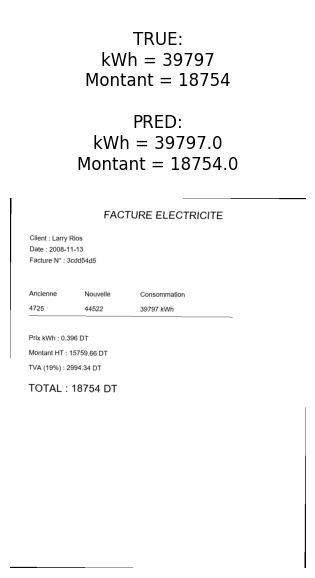

🔎 Sortie brute du modèle :
system
You are a helpful assistant.
user

Extract the following information from this electricity invoice.
Return ONLY a JSON like this:
{
  "consommation_kwh": number,
  "montant_total": number
}

assistant
```json
{
  "consommation_kwh": 39797.0,
  "montant_total": 18754.0
}
```


In [16]:
import matplotlib.pyplot as plt
import json
import re

def extract_json(text):
    try:
        # prendre uniquement après "assistant"
        if "assistant" in text:
            text = text.split("assistant")[-1]

        match = re.search(r'\{[^{}]*\}', text)
        if match:
            return json.loads(match.group())
    except Exception as e:
        print("Erreur parsing:", e)

    return {"consommation_kwh": None, "montant_total": None}


idx = 0  # change l'index pour tester plusieurs images

row = dataset.iloc[idx]

# image
img = Image.open(row["image_path"])

# prediction brute
pred_text = predict(row["image_path"])

# extraction JSON
pred_json = extract_json(pred_text)

# affichage
plt.imshow(img)
plt.title(f"""
TRUE:
kWh = {row['consommation_kwh']}
Montant = {row['montant_total']}

PRED:
kWh = {pred_json['consommation_kwh']}
Montant = {pred_json['montant_total']}
""")
plt.axis('off')
plt.show()

print("🔎 Sortie brute du modèle :")
print(pred_text)

In [17]:
for i in range(5):
    row = dataset.iloc[i]
    pred = predict(row["image_path"])
    pred_json = extract_json(pred)

    print(f"\nImage {i}")
    print("TRUE :", row["consommation_kwh"], row["montant_total"])
    print("PRED :", pred_json)


Image 0
TRUE : 39797 18754
PRED : {'consommation_kwh': 39797.0, 'montant_total': 18754.0}

Image 1
TRUE : 39930 12117
PRED : {'consommation_kwh': 39930.0, 'montant_total': 12117.0}

Image 2
TRUE : 120928 59289
PRED : {'consommation_kwh': 120928.0, 'montant_total': 59289.0}

Image 3
TRUE : 36897 10933
PRED : {'consommation_kwh': 36897.0, 'montant_total': 10933.0}

Image 4
TRUE : 9736 5712
PRED : {'consommation_kwh': 9736.0, 'montant_total': 5712.0}


In [52]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [53]:
model.save_pretrained("qwen_model")
processor.save_pretrained("qwen_model")

['qwen_model/processor_config.json']

## ☀️ Agent solaire (calcul panneaux + coût + ROI)

In [18]:
def estimate_solar_panels(consommation_kwh):
    annual = consommation_kwh * 12

    sun_hours = 1900
    panel_power = 0.4
    efficiency = 0.8

    energy_per_panel = panel_power * sun_hours * efficiency

    panels = annual / energy_per_panel
    return int(panels) + 1


def pricing_agent(num_panels):
    price_panel = 1500
    installation_ratio = 0.2
    inverter_cost = 2000

    panels_cost = num_panels * price_panel
    installation_cost = panels_cost * installation_ratio

    total = panels_cost + installation_cost + inverter_cost
    return total


def roi_analysis(consommation_kwh, total_cost):
    price_kwh = 0.25

    annual_bill = consommation_kwh * 12 * price_kwh
    roi = total_cost / annual_bill

    return round(roi, 2), annual_bill


def solar_agent(consommation_kwh):
    panels = estimate_solar_panels(consommation_kwh)
    total_cost = pricing_agent(panels)
    roi, annual_bill = roi_analysis(consommation_kwh, total_cost)

    if roi < 5:
        decision = "Excellent investissement"
    elif roi < 8:
        decision = "Bon investissement"
    else:
        decision = "À optimiser"

    return {
        "panneaux": panels,
        "cout": total_cost,
        "roi": roi,
        "facture_annuelle": annual_bill,
        "decision": decision
    }

## 📋 Génération du rapport texte

In [19]:
def generate_report(data, result):
    return f"""
🔋 Analyse complète

Consommation : {data['consommation_kwh']} kWh/mois

☀️ Panneaux nécessaires : {result['panneaux']}
💰 Coût estimé : {result['cout']} TND

📈 ROI : {result['roi']} ans
📊 Facture annuelle : {result['facture_annuelle']} TND

💡 Conclusion : {result['decision']}
"""

## 📄 Génération PDF professionnel

In [22]:
!pip install reportlab
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.platypus import Image
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from PIL import Image
from reportlab.platypus import Image as RLImage


def generate_pro_pdf(data, result, filename="/kaggle/working/solar_report_pro.pdf"):
    
    doc = SimpleDocTemplate(
        filename,
        pagesize=A4,
        rightMargin=30, leftMargin=30,
        topMargin=30, bottomMargin=20
    )

    styles = getSampleStyleSheet()

    # 🎨 Styles personnalisés
    title_style = ParagraphStyle(
        'title',
        parent=styles['Title'],
        textColor=colors.darkblue,
        fontSize=22,
        spaceAfter=20
    )

    section_style = ParagraphStyle(
        'section',
        parent=styles['Heading2'],
        textColor=colors.HexColor("#1f77b4"),
        spaceAfter=10
    )

    normal_style = ParagraphStyle(
        'normal',
        parent=styles['Normal'],
        fontSize=11,
        spaceAfter=8
    )

    highlight_style = ParagraphStyle(
        'highlight',
        parent=styles['Normal'],
        textColor=colors.green,
        fontSize=12,
        spaceAfter=10
    )

    content = []

    # 🏷️ Titre
    content.append(Paragraph("☀️ Solar AI Advisor Report", title_style))
    content.append(Spacer(1, 10))

    # 📌 Section Consommation
    content.append(Paragraph("📊 Consommation Énergétique", section_style))
    content.append(Paragraph(
        f"Consommation mensuelle estimée : <b>{data['consommation_kwh']} kWh</b>",
        highlight_style
    ))

    content.append(Spacer(1, 15))

    # 📌 Tableau résultats
    content.append(Paragraph("⚙️ Dimensionnement du Système", section_style))

    table_data = [
        ["Paramètre", "Valeur"],
        ["Nombre de panneaux", result['panneaux']],
        ["Coût total (TND)", f"{result['cout']}"],
        ["Retour sur investissement", f"{result['roi']} ans"]
    ]

    table = Table(table_data, colWidths=[7*cm, 7*cm])

    table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#1f77b4")),
        ('TEXTCOLOR', (0,0), (-1,0), colors.white),

        ('BACKGROUND', (0,1), (-1,-1), colors.whitesmoke),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),

        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('PADDING', (0,0), (-1,-1), 10),

        ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ]))

    content.append(table)
    content.append(Spacer(1, 20))

    # 📌 Conclusion
    content.append(Paragraph("🧠 Analyse & Recommandation", section_style))
    content.append(Paragraph(result['decision'], normal_style))

    content.append(Spacer(1, 20))

    # 📌 Footer
    content.append(Paragraph(
        "Rapport généré automatiquement par Solar AI Advisor",
        ParagraphStyle('footer', fontSize=9, textColor=colors.grey)
    ))

    doc.build(content)

    print("✅ PDF pro généré :", filename)

## 🚀 Pipeline complet (Image → PDF)

In [32]:
image_path = dataset.iloc[1]["image_path"]
image = Image.open(image_path).convert("RGB")

# 1. Extraction
pred = predict(image_path)
data = extract_json(pred)

print("📄 Extraction :", data)

if data["consommation_kwh"] is not None:

    # 2. Agent
    result = solar_agent(data["consommation_kwh"])

    print("\n⚡ Résultat :", result)

    # 3. Rapport texte
    print(generate_report(data, result))

    # 4. PDF
    generate_pro_pdf(data, result)

else:
    print("❌ Extraction échouée")

📄 Extraction : {'consommation_kwh': 39930.0, 'montant_total': 12117.0}

⚡ Résultat : {'panneaux': 789, 'cout': 1422200.0, 'roi': 11.87, 'facture_annuelle': 119790.0, 'decision': 'À optimiser'}

🔋 Analyse complète

Consommation : 39930.0 kWh/mois

☀️ Panneaux nécessaires : 789
💰 Coût estimé : 1422200.0 TND

📈 ROI : 11.87 ans
📊 Facture annuelle : 119790.0 TND

💡 Conclusion : À optimiser

✅ PDF pro généré : /kaggle/working/solar_report_pro.pdf


In [33]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.platypus import Image
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm

def generate_pro_pdf(data, result, filename="/kaggle/working/solar_report_pro.pdf"):
    
    doc = SimpleDocTemplate(
        filename,
        pagesize=A4,
        rightMargin=30, leftMargin=30,
        topMargin=30, bottomMargin=20
    )

    styles = getSampleStyleSheet()

    # 🎨 Styles personnalisés
    title_style = ParagraphStyle(
        'title',
        parent=styles['Title'],
        textColor=colors.darkblue,
        fontSize=22,
        spaceAfter=20
    )

    section_style = ParagraphStyle(
        'section',
        parent=styles['Heading2'],
        textColor=colors.HexColor("#1f77b4"),
        spaceAfter=10
    )

    normal_style = ParagraphStyle(
        'normal',
        parent=styles['Normal'],
        fontSize=11,
        spaceAfter=8
    )

    highlight_style = ParagraphStyle(
        'highlight',
        parent=styles['Normal'],
        textColor=colors.green,
        fontSize=12,
        spaceAfter=10
    )

    content = []

    # 🏷️ Titre
    content.append(Paragraph("☀️ Solar AI Advisor Report", title_style))
    content.append(Spacer(1, 10))

    # 📌 Section Consommation
    content.append(Paragraph("📊 Consommation Énergétique", section_style))
    content.append(Paragraph(
        f"Consommation mensuelle estimée : <b>{data['consommation_kwh']} kWh</b>",
        highlight_style
    ))

    content.append(Spacer(1, 15))

    # 📌 Tableau résultats
    content.append(Paragraph("⚙️ Dimensionnement du Système", section_style))

    table_data = [
        ["Paramètre", "Valeur"],
        ["Nombre de panneaux", result['panneaux']],
        ["Coût total (TND)", f"{result['cout']}"],
        ["Retour sur investissement", f"{result['roi']} ans"]
    ]

    table = Table(table_data, colWidths=[7*cm, 7*cm])

    table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor("#1f77b4")),
        ('TEXTCOLOR', (0,0), (-1,0), colors.white),

        ('BACKGROUND', (0,1), (-1,-1), colors.whitesmoke),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),

        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('PADDING', (0,0), (-1,-1), 10),

        ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ]))

    content.append(table)
    content.append(Spacer(1, 20))

    # 📌 Conclusion
    content.append(Paragraph("🧠 Analyse & Recommandation", section_style))
    content.append(Paragraph(result['decision'], normal_style))

    content.append(Spacer(1, 20))

    # 📌 Footer
    content.append(Paragraph(
        "Rapport généré automatiquement par Solar AI Advisor",
        ParagraphStyle('footer', fontSize=9, textColor=colors.grey)
    ))

    doc.build(content)

    print("✅ PDF pro généré :", filename)

In [48]:
model.save_pretrained("qwen_model")
processor.save_pretrained("qwen_model")

['qwen_model/processor_config.json']